# Underdetermined BSS

Conventional BSS (ICA, SOBI) needs at least as many sensors as sources.
Sparse component analysis (SCA) relaxes that by clustering *real STFT
coefficients*: if two harmonics are linearly mixed *without delay*, the
scatter of $\mathrm{Re}\,G_{x_1}(t,\omega)$ vs $\mathrm{Re}\,G_{x_2}(t,\omega)$
collapses onto straight lines whose slopes are the columns of the mixing
matrix. A **delay** $\delta\neq 0$ turns each line into a Lissajous
ellipse, and SCA fails.

**BSS** (Yu, Shock and Vibration 2019; MATLAB pack originally named
YGBSS after the author's initials) clusters **frequency energy**
instead of the complex STFT values. A delay is a phase factor of unit
modulus, so it drops out of $|G|$. For the band of source $k$,

$$\frac{E_1(\omega)}{E_2(\omega)}=\frac{|a_{1k}|}{|a_{2k}|},\qquad
E_i(\omega)=\sum_t\bigl|G_i(t,\omega)\bigr|^2.$$

Each modal therefore becomes a straight line in the scatter of
$(E_1(\omega),E_2(\omega),\ldots)$, even under delay mixture. The end-point
of each line is a peak of $\sum_i E_i(\omega)$; every other bin whose
energy vector has cosine distance $<\varepsilon$ from that peak belongs
to the same source. Inverse STFT of one observation through that binary
frequency mask recovers the monotone modal. A padding line then
corrects the STFT edge taper.

| | **SCA** | **BSS** (this notebook) |
|---|---|---|
| Feature | $\mathrm{Re}\,G(t,\omega)$ | frequency energy $E(\omega)$ |
| Instantaneous mix | straight lines | straight lines |
| Delay mix | Lissajous ellipses | still straight lines |
| Reconstruction | linear program / $\ell_1$ | inverse STFT of a mask |

The MATLAB driver uses $\sum_t |G|^2$ (not the paper's $\int|G|\,dt$)
and raises the padding ratio to $1/1.6$. This notebook follows the
code.

**Reference**

> G. Yu, *An Underdetermined Blind Source Separation Method with
> Application to Modal Identification*, Shock and Vibration 2019,
> Article ID 1637163.


## 1. Imports


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit.data import load_bss_beam, load_bss_yk9
from pysdkit.utils import (
    BSS,
    frequency_axis_stft,
    modal_assurance_criterion,
    mrsp2mpfd,
    sign_from_correlation,
)
from pysdkit.utils.bss import bss

print("pysdkit from:", Path(__import__("pysdkit").__file__).resolve())
print(BSS())

pysdkit from: C:\Users\HUAWEI\Desktop\PySDKit\pysdkit\__init__.py
Underdetermined BSS


## 2. What the code computes

1. Odd Hamming window $L$ (default odd $\lfloor T/4\rfloor$), MATLAB
   `hamming(L)`, unit energy.
2. TFTB STFT $G_i(t,\omega)$ of every channel (`tfrstft`, $N=T$ bins).
3. Frequency energy $E_i(\omega)=\sum_t |G_i(t,\omega)|^2$.
4. Peak detection on $\sum_i E_i$ with $\delta=e_1\max|\sum E|$
   (Billauer `peakdet`). Keep the first half of the peaks (positive
   frequencies of a two-sided FFT).
5. For each peak $\omega_p$ and bin $\omega$, set the mask if
   $\sum_i E_i(\omega)>e_3\sum_i E_i(\omega_p)$ and the cosine
   distance of the energy vectors is $<e_2$ (default $0.004$).
6. Inverse STFT of channel `channel` (default 0) through each mask;
   multiply by the padding line
   $L(t)=\bigl(\sum g/\sum_{\mathrm{overlap}} g\bigr)^{1/1.6}$.
7. Mixing / mode-shape columns: $\sqrt{E(\omega_p)}$, then $\ell_2$
   column-normalised (absolute values; signs from `corr` in the
   experiments).


In [2]:
def plot_channels(data, fs, title, ylabel="Amplitude"):
    data = np.asarray(data)
    n_rows = data.shape[0]
    time = np.arange(data.shape[1], dtype=float) / float(fs)
    fig, axes = plt.subplots(n_rows, 1, sharex=True, figsize=(9, 1.6 * n_rows))
    if n_rows == 1:
        axes = [axes]
    for idx, ax in enumerate(axes):
        ax.plot(time, data[idx], lw=0.8)
        ax.set_ylabel(ylabel)
    axes[0].set_title(title)
    axes[-1].set_xlabel("Time (s)")
    fig.tight_layout()
    return fig


def plot_spectra(data, fs, title, f_max=None):
    data = np.asarray(data)
    n_rows = data.shape[0]
    freq = np.fft.rfftfreq(data.shape[1], d=1.0 / float(fs))
    fig, axes = plt.subplots(n_rows, 1, sharex=True, figsize=(9, 1.6 * n_rows))
    if n_rows == 1:
        axes = [axes]
    for idx, ax in enumerate(axes):
        ax.plot(freq, np.abs(np.fft.rfft(data[idx])), lw=0.8)
        ax.set_ylabel("|X|")
        if f_max is not None:
            ax.set_xlim(0, f_max)
    axes[0].set_title(title)
    axes[-1].set_xlabel("Frequency (Hz)")
    fig.tight_layout()
    return fig


def plot_energy_scatter(engine, title="Frequency-energy scatter"):
    energy = engine.energy_
    peaks = engine.peaks_
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(energy[0], energy[1], ".", ms=2, alpha=0.5)
    axes[0].plot(energy[0, peaks], energy[1, peaks], "*", color="C3", ms=10)
    axes[0].set_xlabel("$E_1(\\omega)$")
    axes[0].set_ylabel("$E_2(\\omega)$")
    axes[0].set_title(title)
    energy_sum = np.sum(energy, axis=0)
    freq = frequency_axis_stft(energy_sum.size)
    axes[1].plot(freq, energy_sum, lw=0.9)
    axes[1].plot(freq[peaks], energy_sum[peaks], "*", color="C3", ms=10)
    axes[1].set_xlabel("Normalised frequency")
    axes[1].set_ylabel("$\\sum_i E_i$")
    axes[1].set_title("Peak detection")
    fig.tight_layout()
    return fig

## 3. Example 1 — five sources, two delayed observations

MATLAB `Example_1.m`. Five tones at $3,6,10,15,20$ Hz, $F_s=100$ Hz,
$t\in[0,10)$. Channel 2 is a **circular delay of 4 samples** of each
tone (the delay mixture that breaks SCA):

$$\begin{aligned}
x_1&=s_1+0.8s_2+0.5s_3+0.3s_4+0.7s_5,\\
x_2&=0.5 s_1(t-\tau)+0.8 s_2(t-\tau)+0.95 s_3(t-\tau)\\
&\quad+1.1 s_4(t-\tau)+0.15 s_5(t-\tau).
\end{aligned}$$


sources (5, 1000) peaks (bins) [ 30  60 100 150 200]
FFT peaks (Hz) [3.0, 6.0, 10.0, 15.0, 20.0]


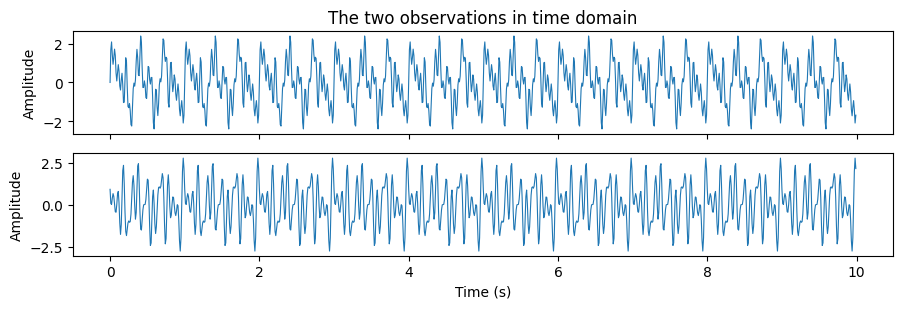

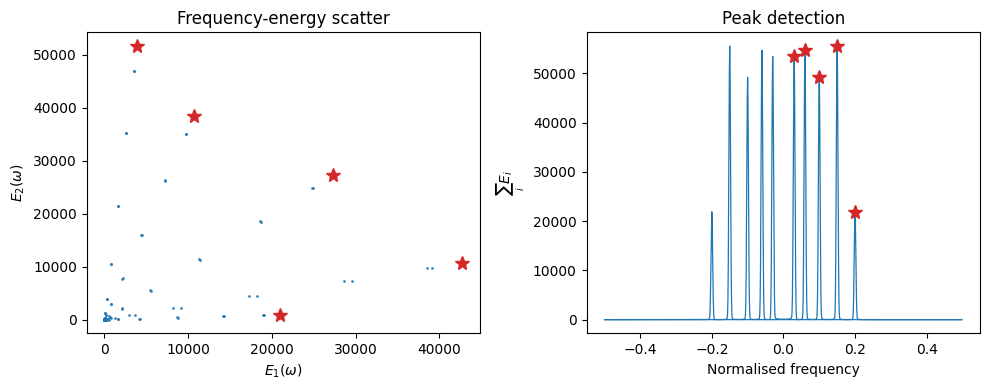

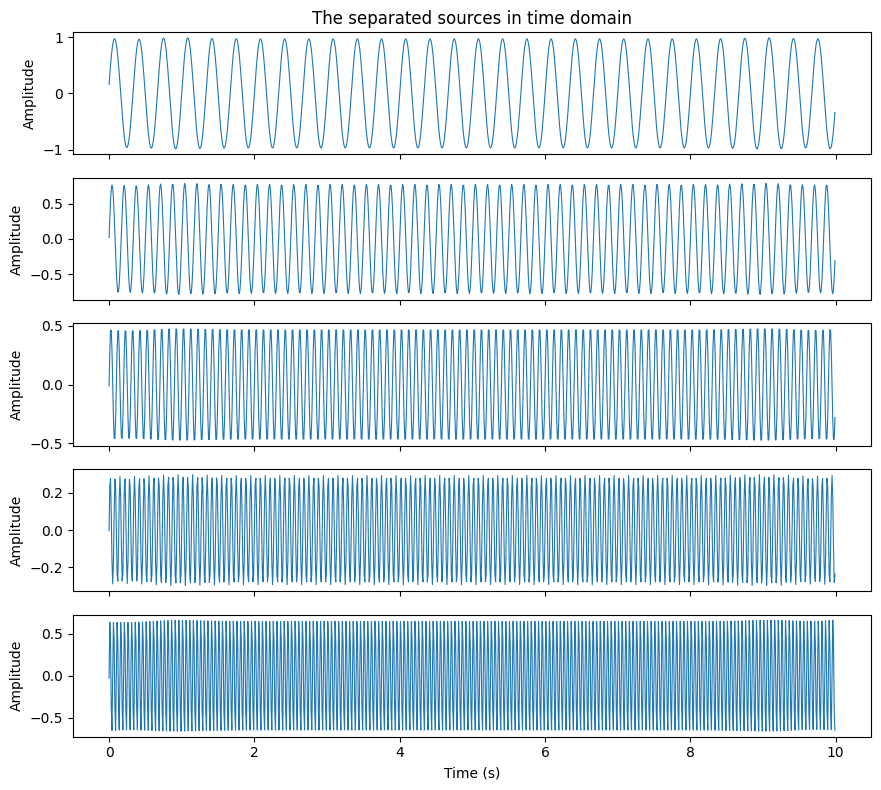

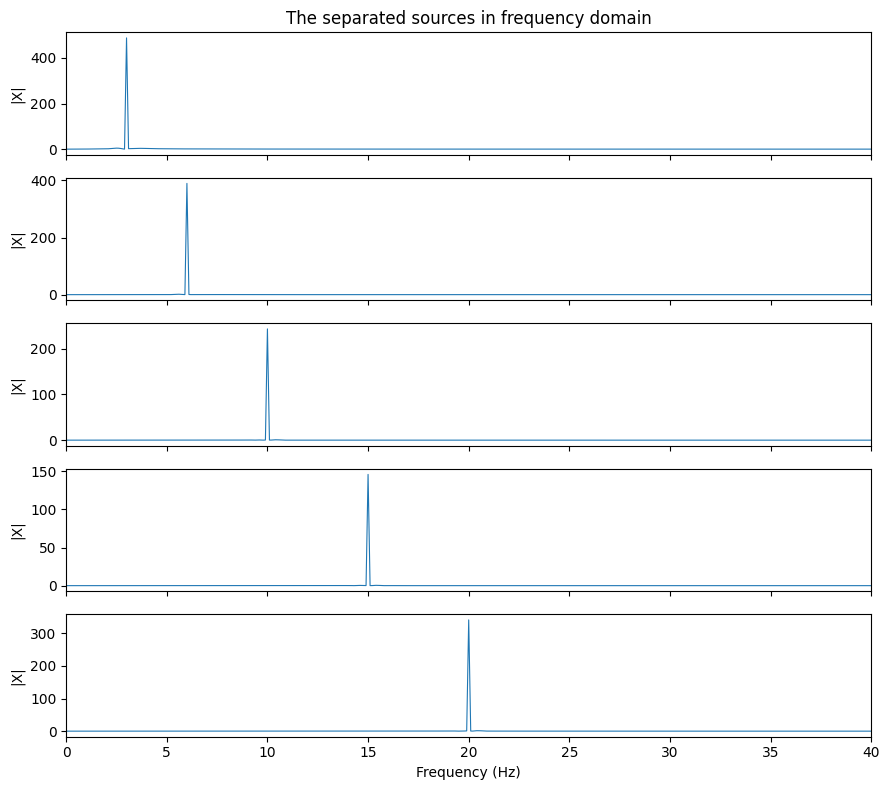

In [3]:
fs = 100.0
time = np.arange(0.0, 10.0, 1.0 / fs)
tones = [np.sin(2 * np.pi * freq * time) for freq in (3, 6, 10, 15, 20)]


def delay(samples, shift=4):
    return np.concatenate([samples[shift:], samples[:shift]])


weights_1 = (1.0, 0.8, 0.5, 0.3, 0.7)
weights_2 = (0.5, 0.8, 0.95, 1.1, 0.15)
x1 = sum(w * s for w, s in zip(weights_1, tones))
x2 = sum(w * delay(s) for w, s in zip(weights_2, tones))
mixtures = np.vstack([x1, x2])

engine = BSS()
sources = engine.fit_transform(mixtures)
print("sources", sources.shape, "peaks (bins)", engine.peaks_)
print(
    "FFT peaks (Hz)",
    [
        float(
            np.fft.rfftfreq(sources.shape[1], d=1 / fs)[
                int(np.argmax(np.abs(np.fft.rfft(row))))
            ]
        )
        for row in sources
    ],
)

plot_channels(mixtures, fs, "The two observations in time domain")
plot_energy_scatter(engine)
plot_channels(sources, fs, "The separated sources in time domain")
plot_spectra(sources, fs, "The separated sources in frequency domain", f_max=40)
plt.show()

Noisy run from `Example_1.m`: the same mixture plus $0.5\,\mathcal{N}(0,1)$
on each channel (seeded here so the notebook is repeatable).


noisy sources (5, 1000)


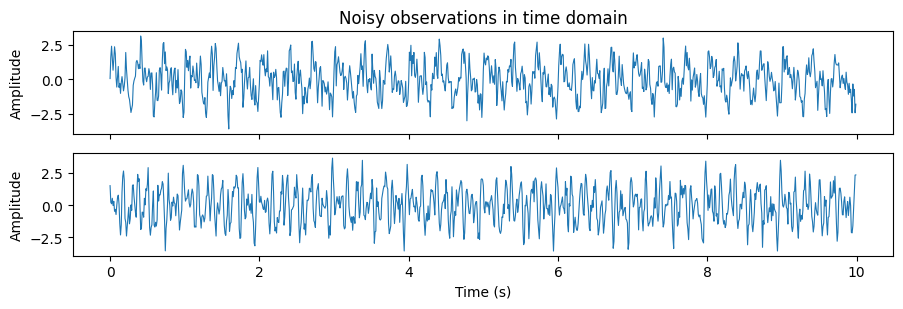

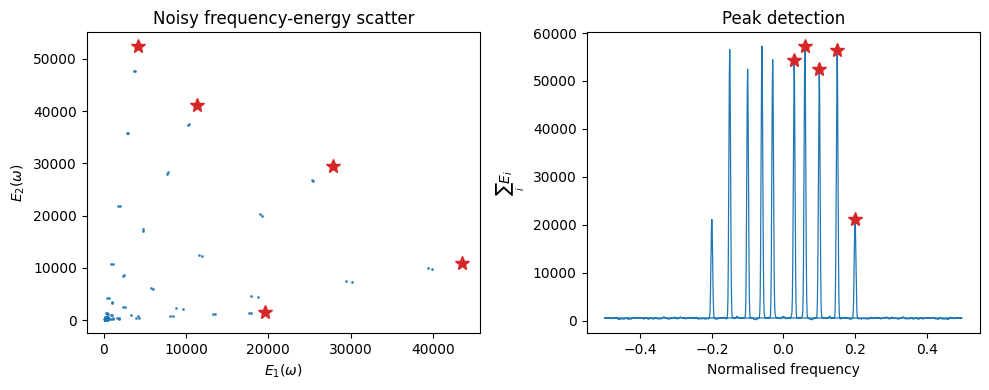

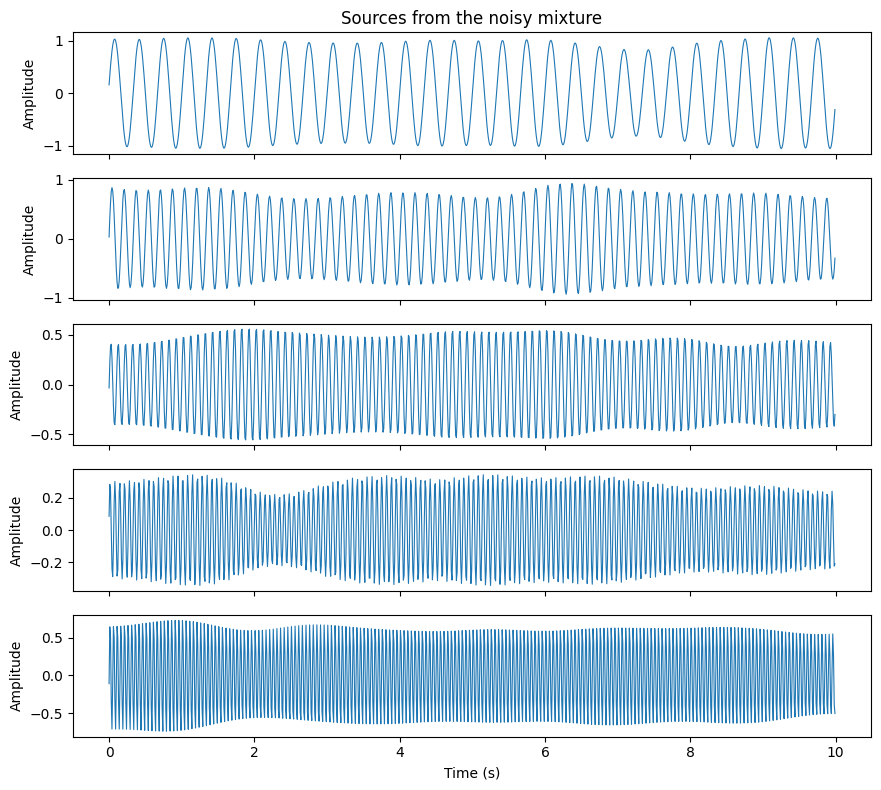

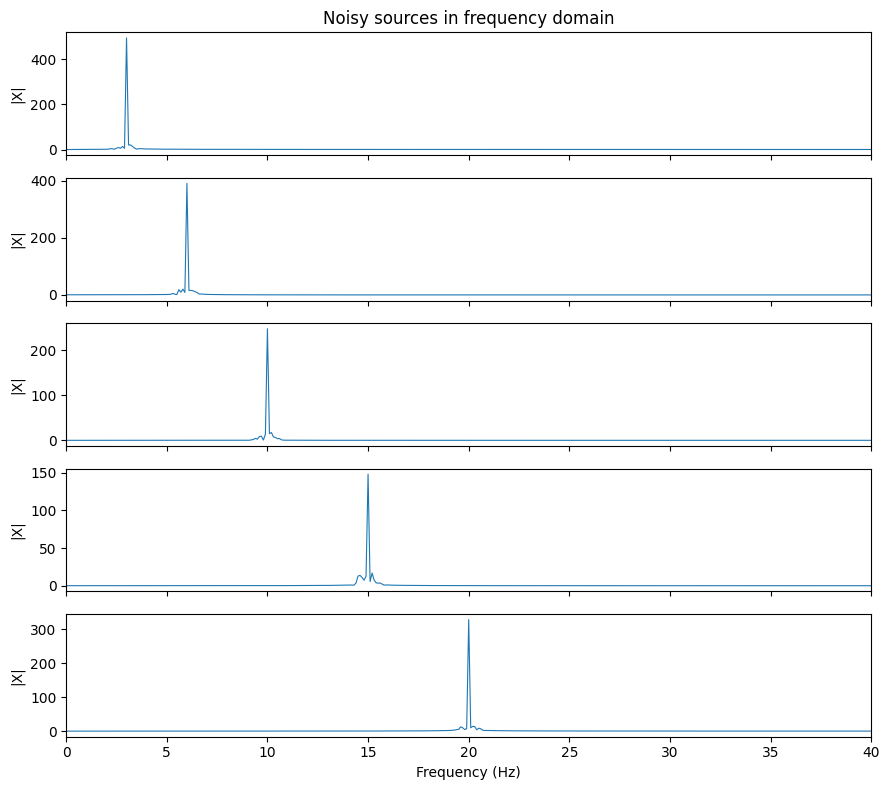

In [4]:
rng = np.random.default_rng(0)
noisy = mixtures + 0.5 * rng.standard_normal(mixtures.shape)
noisy_engine = BSS()
noisy_sources = noisy_engine.fit_transform(noisy)
print("noisy sources", noisy_sources.shape)

plot_channels(noisy, fs, "Noisy observations in time domain")
plot_energy_scatter(noisy_engine, "Noisy frequency-energy scatter")
plot_channels(noisy_sources, fs, "Sources from the noisy mixture")
plot_spectra(noisy_sources, fs, "Noisy sources in frequency domain", f_max=40)
plt.show()

## 4. Paper §3.2 — five instantaneous tones in noise

The journal numerical example (not the MATLAB delay demo) mixes five
tones at $30,70,110,150,190$ Hz into two *instantaneous* observations,
$F_s=512$ Hz, $t\in[0,2)$:

$$\begin{aligned}
S_1&=\sin(2\pi 30 t)+\sin(2\pi 70 t)+\sin(2\pi 110 t)+\sin(2\pi 150 t)+\sin(2\pi 190 t),\\
S_2&=0.5\sin(2\pi 30 t)+0.9\sin(2\pi 70 t)+1.3\sin(2\pi 110 t)\\
&\quad+1.7\sin(2\pi 150 t)+2.2\sin(2\pi 190 t).
\end{aligned}$$


paper sources (5, 1024)
FFT peaks (Hz) [30.0, 70.0, 110.0, 150.0, 190.0]


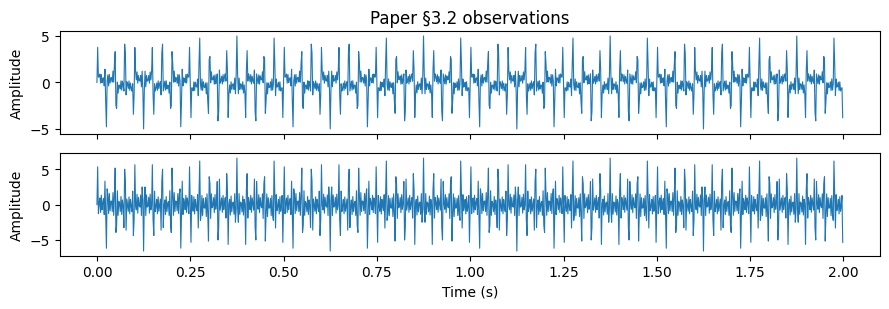

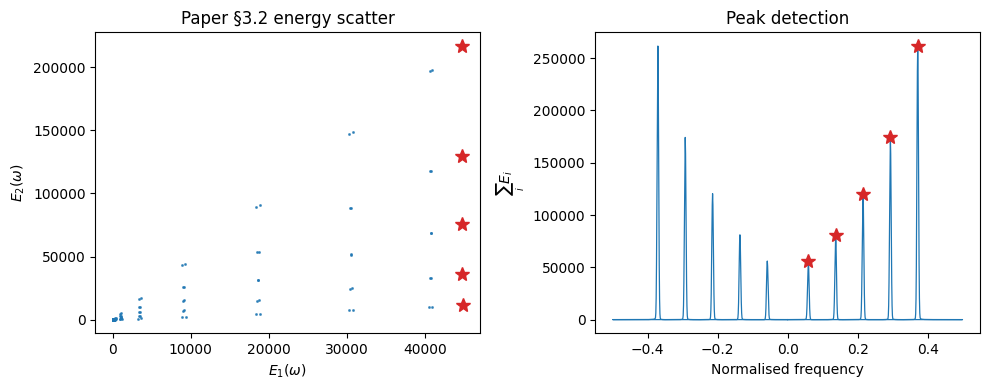

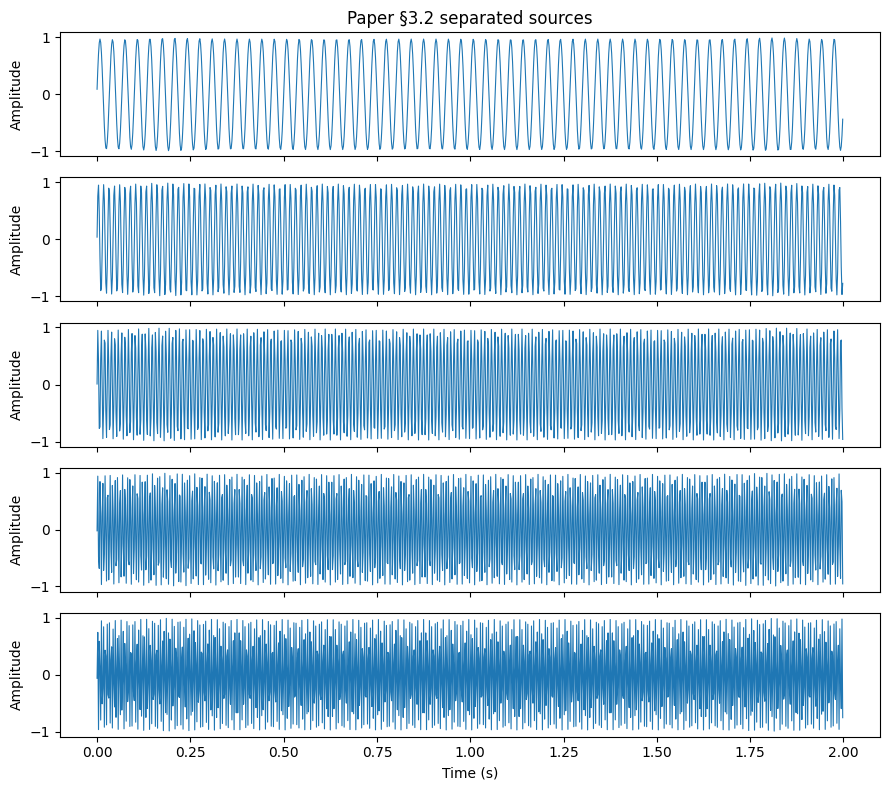

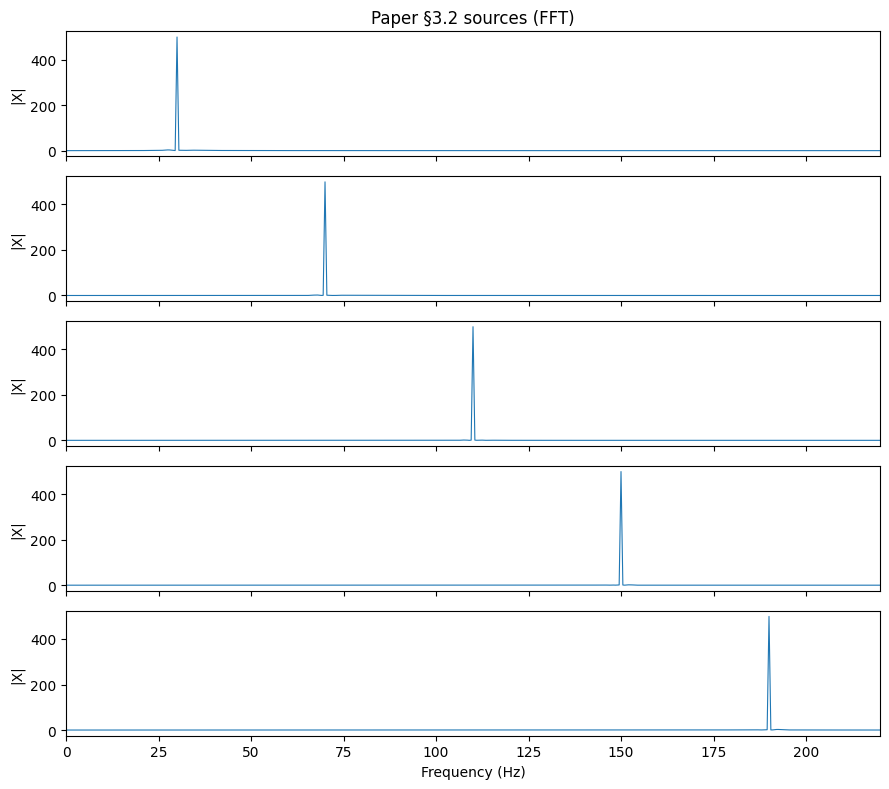

In [5]:
fs_p = 512.0
time_p = np.arange(0.0, 2.0, 1.0 / fs_p)
freqs_p = (30.0, 70.0, 110.0, 150.0, 190.0)
w1 = (1.0, 1.0, 1.0, 1.0, 1.0)
w2 = (0.5, 0.9, 1.3, 1.7, 2.2)
sines = [np.sin(2 * np.pi * f * time_p) for f in freqs_p]
paper_mix = np.vstack(
    [
        sum(w * s for w, s in zip(w1, sines)),
        sum(w * s for w, s in zip(w2, sines)),
    ]
)
paper_engine = BSS()
paper_sources = paper_engine.fit_transform(paper_mix)
print("paper sources", paper_sources.shape)
print(
    "FFT peaks (Hz)",
    [
        float(
            np.fft.rfftfreq(paper_sources.shape[1], d=1 / fs_p)[
                int(np.argmax(np.abs(np.fft.rfft(row))))
            ]
        )
        for row in paper_sources
    ],
)

plot_channels(paper_mix, fs_p, "Paper §3.2 observations")
plot_energy_scatter(paper_engine, "Paper §3.2 energy scatter")
plot_channels(paper_sources, fs_p, "Paper §3.2 separated sources")
plot_spectra(paper_sources, fs_p, "Paper §3.2 sources (FFT)", f_max=220)
plt.show()

## 5. Example 2 / Experiment 1 — three-sensor beam

MATLAB `Example_2.m` / paper §4.1. Uniform TC4 beam, three
accelerometers, impact hammer, $F_s=2560$ Hz, first $0.5$ s
(`load_bss_beam()`, already linearly detrended). Call
`BSS(window_length=321, e1=0.01)` (MATLAB `YGBSS(X, 321, 0.01)`).

Paper Table 1 (proposed method): $30.78$, $215.6$, $585.9$,
$1115.3$ Hz with damping $2.863$, $0.505$, $0.585$, $0.234\,\%$.


beam (3, 1280) fs 2560.0
beam sources (4, 1280)


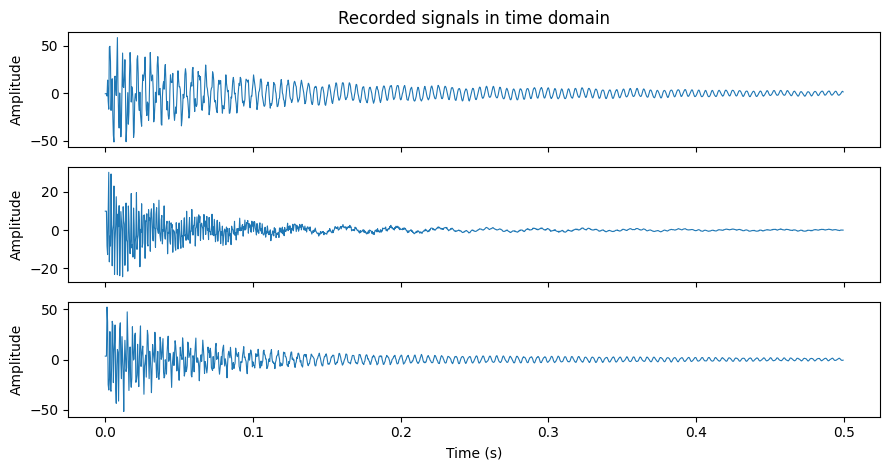

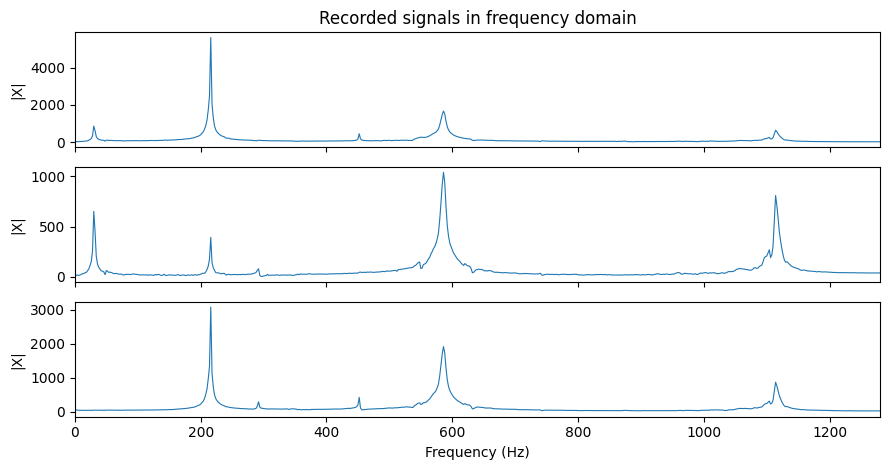

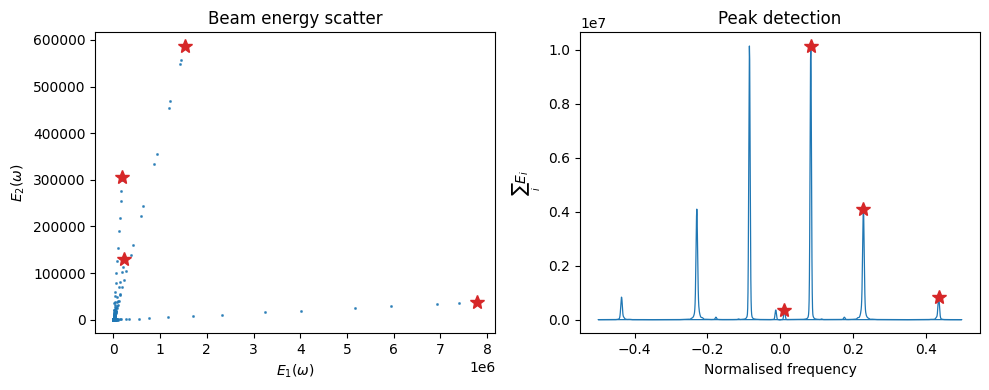

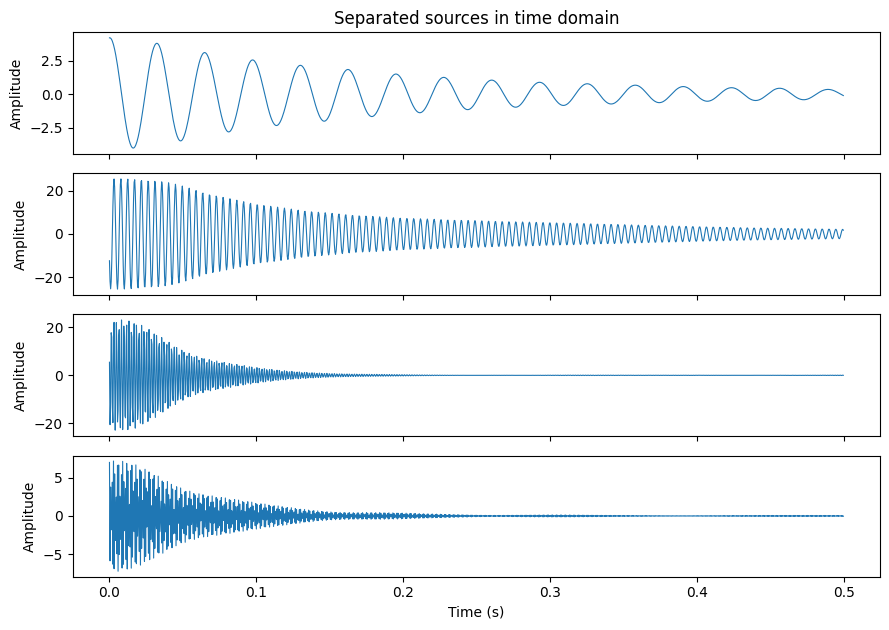

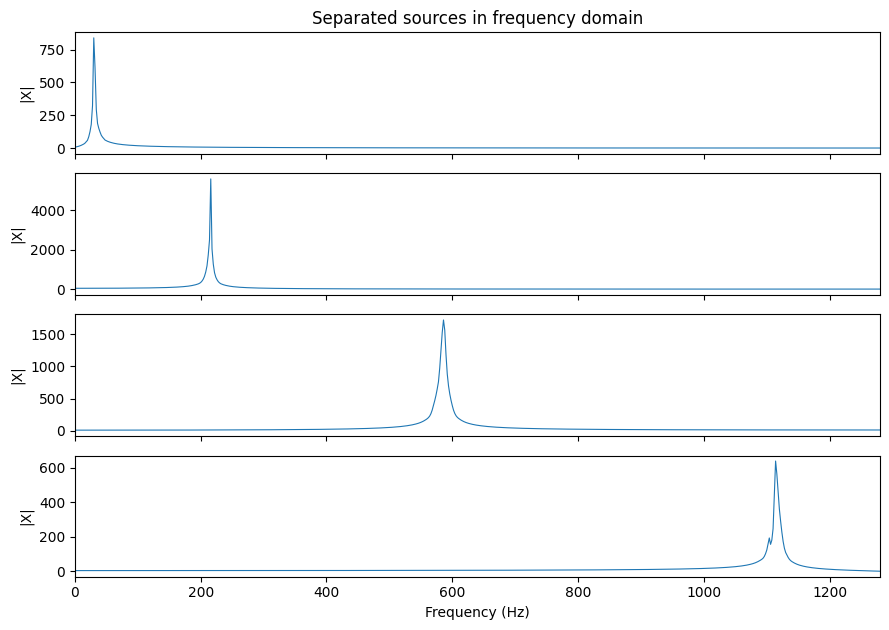

MAC
[[0.9981 0.5167 0.095  0.    ]
 [0.5384 0.9999 0.0432 0.4779]
 [0.0659 0.034  0.9991 0.0065]
 [0.     0.4549 0.0079 0.9996]]
MAC diagonal [0.9981 0.9999 0.9991 0.9996]


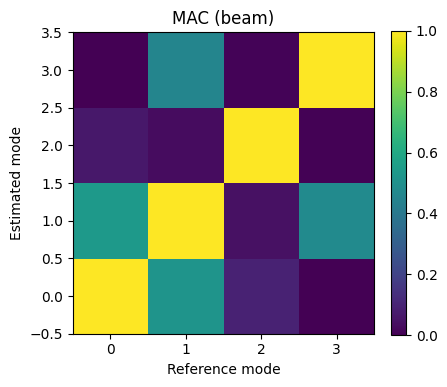

fd (Hz) [  30.79  215.61  585.91 1115.28]
fn (Hz) [  30.77  215.61  585.9  1115.28]
damping % [2.863 0.504 0.585 0.234]
paper Table 1 fd ~ [30.78, 215.6, 585.9, 1115.3]


In [6]:
beam = load_bss_beam()
X_beam = beam["signal"]
fs_beam = beam["fs"]
print("beam", X_beam.shape, "fs", fs_beam)

beam_engine = BSS(window_length=321, e1=0.01)
beam_sources = beam_engine.fit_transform(X_beam)
print("beam sources", beam_sources.shape)

plot_channels(X_beam, fs_beam, "Recorded signals in time domain")
plot_spectra(X_beam, fs_beam, "Recorded signals in frequency domain", f_max=1280)
plot_energy_scatter(beam_engine, "Beam energy scatter")
plot_channels(beam_sources, fs_beam, "Separated sources in time domain")
plot_spectra(beam_sources, fs_beam, "Separated sources in frequency domain", f_max=1280)
plt.show()

signed = beam_engine.mixing_ * sign_from_correlation(beam_sources, X_beam)
n_ref = beam["mode_shape"].shape[1]
mac = modal_assurance_criterion(signed[:, :n_ref], beam["mode_shape"])
print("MAC")
print(np.round(mac, 4))
print("MAC diagonal", np.round(np.diag(mac), 4))

fig, ax = plt.subplots(figsize=(4.5, 4))
image = ax.imshow(mac, origin="lower", vmin=0.0, vmax=1.0, cmap="viridis")
ax.set_xlabel("Reference mode")
ax.set_ylabel("Estimated mode")
ax.set_title("MAC (beam)")
fig.colorbar(image, ax=ax, fraction=0.046)
fig.tight_layout()
plt.show()

params = mrsp2mpfd(beam_sources[:n_ref], fs_beam)
print("fd (Hz)", np.round(params["fd"], 2))
print("fn (Hz)", np.round(params["fn"], 2))
print("damping %", np.round(params["z"], 3))
print("paper Table 1 fd ~", [30.78, 215.6, 585.9, 1115.3])

## 6. Example 3 / Experiment 2 — five-sensor cantilever (three used)

MATLAB `Example_3.m` / paper §4.2. Steel cantilever, five displacement
sensors; the demo keeps channels 1, 2 and 5 (`load_bss_yk9()`),
first 1000 samples. A very small peak threshold $e_1=10^{-4}$ is
needed so the weak fifth modal is not missed. Window length 351.


yk9 (3, 1000) fs 1536.9571947416507
yk9 sources (5, 1000)


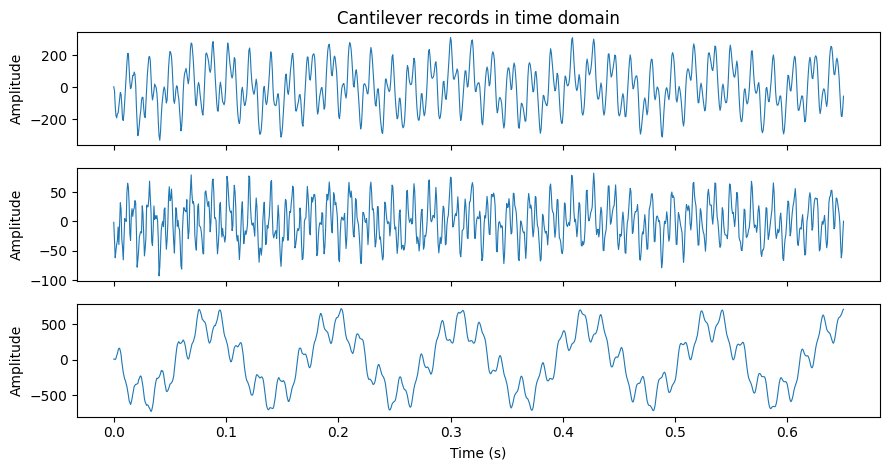

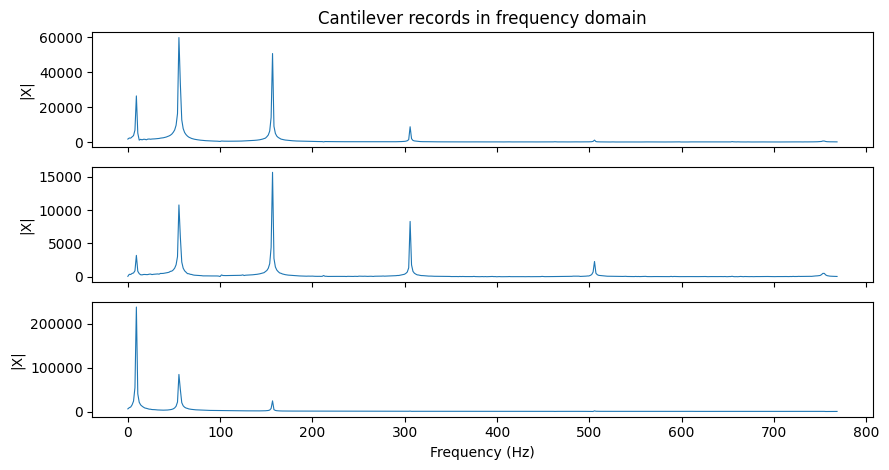

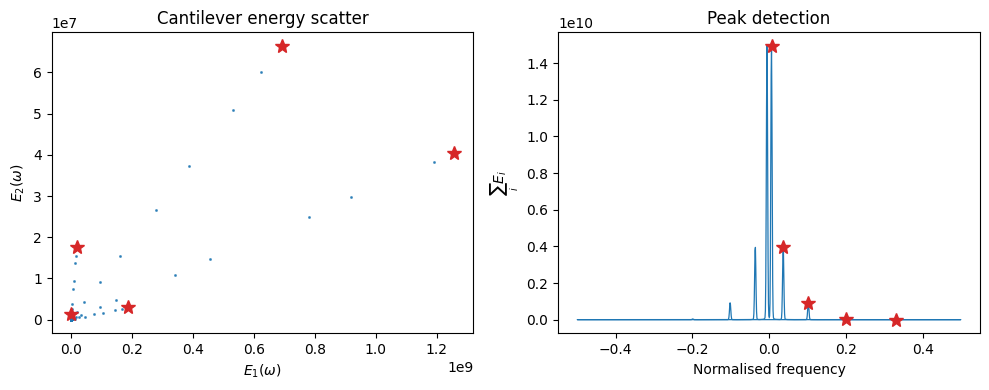

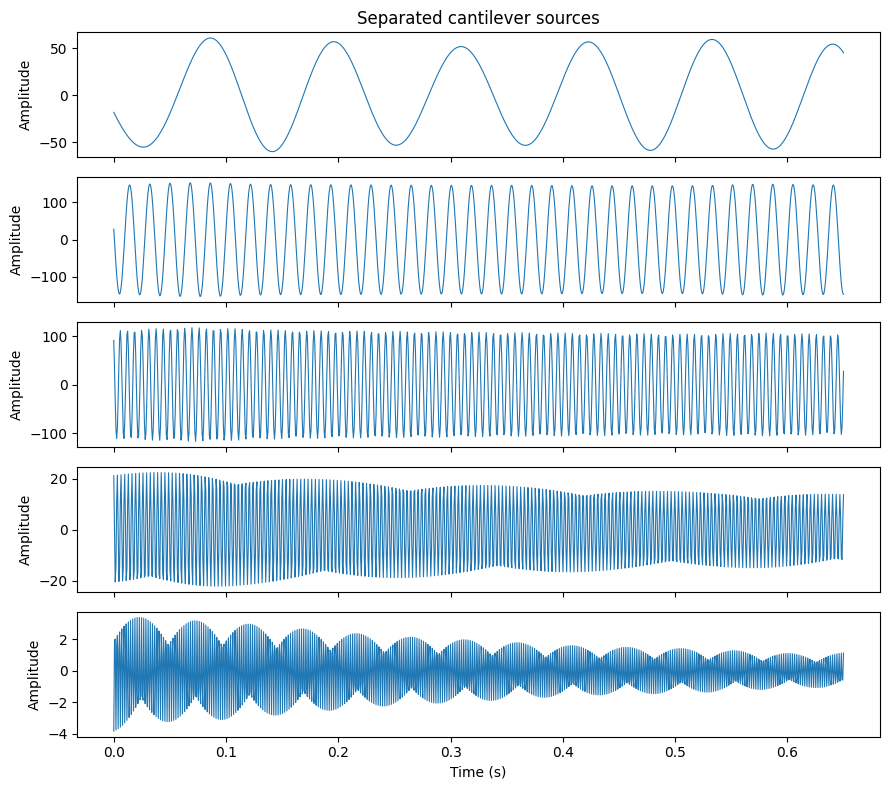

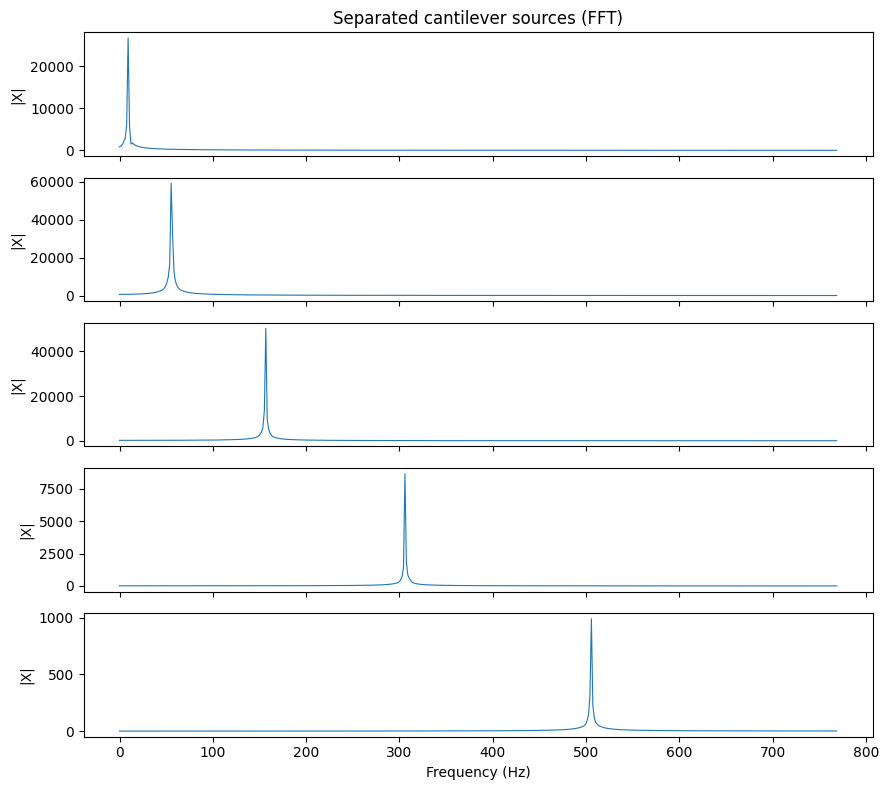

MAC
[[1.     0.5774 0.2582 0.0022 0.1146]
 [0.5571 0.9997 0.034  0.2707 0.6503]
 [0.2677 0.0261 0.9999 0.642  0.2326]
 [0.0325 0.1554 0.7244 0.9823 0.1424]
 [0.3307 0.1074 0.1133 0.0719 0.0865]]
MAC diagonal [1.     0.9997 0.9999 0.9823 0.0865]


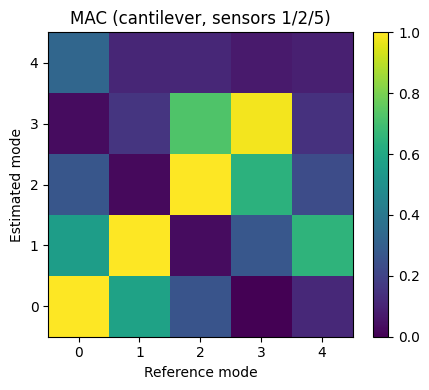

fd (Hz) [  8.96  55.86 156.44 306.1  505.39]
fn (Hz) [  8.96  55.86 156.44 306.1  505.39]
damping % [ 0.742 -0.014  0.017  0.044  0.06 ]


In [7]:
yk9 = load_bss_yk9()
X_yk = yk9["signal"]
fs_yk = yk9["fs"]
print("yk9", X_yk.shape, "fs", fs_yk)

yk_engine = BSS(window_length=351, e1=1e-4)
yk_sources = yk_engine.fit_transform(X_yk)
print("yk9 sources", yk_sources.shape)

plot_channels(X_yk, fs_yk, "Cantilever records in time domain")
plot_spectra(X_yk, fs_yk, "Cantilever records in frequency domain")
plot_energy_scatter(yk_engine, "Cantilever energy scatter")
plot_channels(yk_sources, fs_yk, "Separated cantilever sources")
plot_spectra(yk_sources, fs_yk, "Separated cantilever sources (FFT)")
plt.show()

signed_yk = yk_engine.mixing_ * sign_from_correlation(yk_sources, X_yk)
n_yk = min(signed_yk.shape[1], yk9["mode_shape"].shape[1])
mac_yk = modal_assurance_criterion(signed_yk[:, :n_yk], yk9["mode_shape"][:, :n_yk])
print("MAC")
print(np.round(mac_yk, 4))
print("MAC diagonal", np.round(np.diag(mac_yk), 4))

fig, ax = plt.subplots(figsize=(4.8, 4))
image = ax.imshow(mac_yk, origin="lower", vmin=0.0, vmax=1.0, cmap="viridis")
ax.set_xlabel("Reference mode")
ax.set_ylabel("Estimated mode")
ax.set_title("MAC (cantilever, sensors 1/2/5)")
fig.colorbar(image, ax=ax, fraction=0.046)
fig.tight_layout()
plt.show()

params_yk = mrsp2mpfd(yk_sources, fs_yk)
print("fd (Hz)", np.round(params_yk["fd"], 2))
print("fn (Hz)", np.round(params_yk["fn"], 2))
print("damping %", np.round(params_yk["z"], 3))

## 7. Convenience wrapper

`bss(X, **kwargs)` (from `pysdkit.utils.bss`) returns `(sources, mixing)`
— the same pair as MATLAB `[source, A] = YGBSS(X, ...)`.


In [8]:
src, mixing = bss(mixtures)
print(src.shape, mixing.shape)
print("column norms", np.round(np.linalg.norm(mixing, axis=0), 6))

(5, 1000) (2, 5)
column norms [1. 1. 1. 1. 1.]
